# Homework 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Read in the csv files
unrate = pd.read_csv('UNRATE.csv')
unrate

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5
...,...,...
939,2026-04-01,4.3
940,2026-05-01,4.3
941,2026-06-01,4.2
942,2026-07-01,4.1


In [3]:
usrec= pd.read_csv('USREC.csv')
usrec

,observation_date,USREC
0,1854-12-01,1
1,1855-01-01,0
2,1855-02-01,0
3,1855-03-01,0
4,1855-04-01,0
...,...,...
2056,2026-04-01,0
2057,2026-05-01,0
2058,2026-06-01,0
2059,2026-07-01,0


In [4]:
#Merge the two on observation_date
date_merge = usrec.merge(unrate, on='observation_date')
date_merge

,observation_date,USREC,UNRATE
0,1948-01-01,0,3.4
1,1948-02-01,0,3.8
2,1948-03-01,0,4.0
3,1948-04-01,0,3.9
4,1948-05-01,0,3.5
...,...,...,...
939,2026-04-01,0,4.3
940,2026-05-01,0,4.3
941,2026-06-01,0,4.2
942,2026-07-01,0,4.1


In [5]:
# set the date as the index. [[ ]] would give a DataFrame as the index, [] gives a series.
date_merge.index= date_merge['observation_date']
date_merge

,observation_date,USREC,UNRATE
observation_date,,,
1948-01-01,1948-01-01,0,3.4
1948-02-01,1948-02-01,0,3.8
1948-03-01,1948-03-01,0,4.0
1948-04-01,1948-04-01,0,3.9
1948-05-01,1948-05-01,0,3.5
...,...,...,...
2026-04-01,2026-04-01,0,4.3
2026-05-01,2026-05-01,0,4.3
2026-06-01,2026-06-01,0,4.2


In [6]:
#Add a column with the monthly change in unemployment (.diff()).
unemploy_change = date_merge.copy()
unemploy_change.insert(3,'delta_unrate_per_mo', unemploy_change['UNRATE'].diff())
unemploy_change

,observation_date,USREC,UNRATE,delta_unrate_per_mo
observation_date,,,,
1948-01-01,1948-01-01,0,3.4,NaN
1948-02-01,1948-02-01,0,3.8,0.4
1948-03-01,1948-03-01,0,4.0,0.2
1948-04-01,1948-04-01,0,3.9,-0.1
1948-05-01,1948-05-01,0,3.5,-0.4
...,...,...,...,...
2026-04-01,2026-04-01,0,4.3,0.0
2026-05-01,2026-05-01,0,4.3,0.0
2026-06-01,2026-06-01,0,4.2,-0.1


In [7]:
#Use groupby to compare the average change in recession vs. expansion months.
change_rec_vs_exp = unemploy_change.groupby('USREC')
change_rec_vs_exp['delta_unrate_per_mo'].mean()

USREC
0   -0.050673
1    0.338710
Name: delta_unrate_per_mo, dtype: float64

In [8]:
#What was the mean unemployment rate between 2010 and 2020?
#Currently, our index is not a TimeSeries
type(unemploy_change.index)

pandas.Index

In [9]:
#So, let's turn our index into a TimeSeries!
unemploy_change.index = pd.to_datetime(unemploy_change.index)
#And then, we slice by year.
#Wasn't sure if you meant 'between' 2020 as excluding or including the year 2020,
#So the first option gives the mean unemployment rate inclusive of 2020
print(unemploy_change['2010':'2020']['UNRATE'].mean())

6.391666666666667


In [10]:
#And this second option gives the mean unemployment rate exclusive of 2020 (just through 2019)
#So that all my bases are covered for this assignment
print(unemploy_change['2010':'2019']['UNRATE'].mean())

6.220833333333333


Text(0.06, 0.01, 'Source: BLS and NBER via FRED (UNRATE, USREC). October 2025 not collected.')

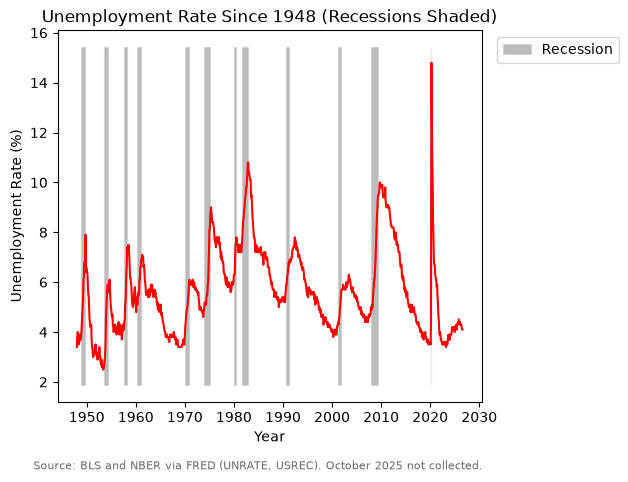

In [11]:
#Plot unemployment since 1948 with recessions shaded (hint:
#plt.fill_between). Include a title, axis labels, legend, and source
#note).
x = unemploy_change.index
y = unemploy_change['UNRATE']
#Shading values are when 'USREC' = 1
shade = unemploy_change['USREC'] != 0

#Create a basic pair of axes
fig = plt.figure()
ax = fig.add_subplot(111)
#Plot the data
plt.plot(x,y, 'r-')
#Capture the axis limits (xmin, xmax, ymin, ymax)
limits = plt.axis()
ax.fill_between(x, limits[2], limits[3], where=shade,  edgecolor='#BBBBBB', facecolor='#222222', alpha=0.3, label='Recession')
#Title
ax.set_title('Unemployment Rate Since 1948 (Recessions Shaded)')
#Axis titles
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
#Claude-generated code to place my legend off to the side of the chart (bbox is the Claude part)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
#If I were to plot my axis normally, I'd use plt.legend(), or perhaps plt.legend(loc=0)
#Part of the Claude solution for the legend off-chart, to ensure the legend doesn't get cut off
fig.tight_layout(rect=(0, 0.03, 1, 1))
#Source note
fig.text(0.06, 0.01, 'Source: BLS and NBER via FRED (UNRATE, USREC). '
         'October 2025 not collected.', fontsize=8, color='dimgray')